# 6 - Deep Q-Network

## Problem Definition

A gaming company wants to train intelligent agents directly from environment observations

In [1]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque
import matplotlib.pyplot as plt

In [2]:
# 1. Neural Network to Approximate Q-Values
class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(QNetwork, self).__init__()
        self.fc1 = nn.Linear(state_dim, 64)
        self.fc2 = nn.Linear(64, 64)
        self.out = nn.Linear(64, action_dim)

    def forward(self, state):
        x = torch.relu(self.fc1(state))
        x = torch.relu(self.fc2(x))
        return self.out(x)


# 2. Experience Replay Buffer
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        state, action, reward, next_state, done = map(np.stack, zip(*batch))
        return state, action, reward, next_state, done

    def __len__(self):
        return len(self.buffer)


# 3. DQN Agent
class DQNAgent:
    def __init__(
        self,
        state_dim,
        action_dim,
        lr=1e-3,
        gamma=0.99,
        buffer_size=10000,
        target_update_freq=10,
    ):
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.gamma = gamma
        self.target_update_freq = target_update_freq
        self.train_step_counter = 0

        # Main Network and Target Network
        self.q_net = QNetwork(state_dim, action_dim)
        self.target_net = QNetwork(state_dim, action_dim)
        self.target_net.load_state_dict(self.q_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.q_net.parameters(), lr=lr)
        self.memory = ReplayBuffer(buffer_size)

    def select_action(self, state, epsilon):
        if random.random() < epsilon:
            return random.randint(0, self.action_dim - 1)
        state_tensor = torch.FloatTensor(state).unsqueeze(0)
        with torch.no_grad():
            q_values = self.q_net(state_tensor)
        return q_values.argmax().item()

    def train_step(self, batch_size):
        if len(self.memory) < batch_size:
            return

        states, actions, rewards, next_states, dones = self.memory.sample(batch_size)

        states = torch.FloatTensor(states)
        actions = torch.LongTensor(actions).unsqueeze(1)
        rewards = torch.FloatTensor(rewards).unsqueeze(1)
        next_states = torch.FloatTensor(next_states)
        dones = torch.FloatTensor(dones).unsqueeze(1)

        # Current Q values
        q_values = self.q_net(states).gather(1, actions)

        # Target Q values using the Target Network
        with torch.no_grad():
            max_next_q_values = self.target_net(next_states).max(1)[0].unsqueeze(1)
            target_q_values = rewards + (self.gamma * max_next_q_values * (1 - dones))

        # Compute MSE Loss
        loss = nn.MSELoss()(q_values, target_q_values)

        # Optimize the model
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        self.train_step_counter += 1
        # Update Target Network periodically
        if self.train_step_counter % self.target_update_freq == 0:
            self.target_net.load_state_dict(self.q_net.state_dict())

Training Baseline DQN...
Training DQN with Small Replay Buffer (Size=500)...
Training DQN with Infrequent Target Update (Freq=100)...


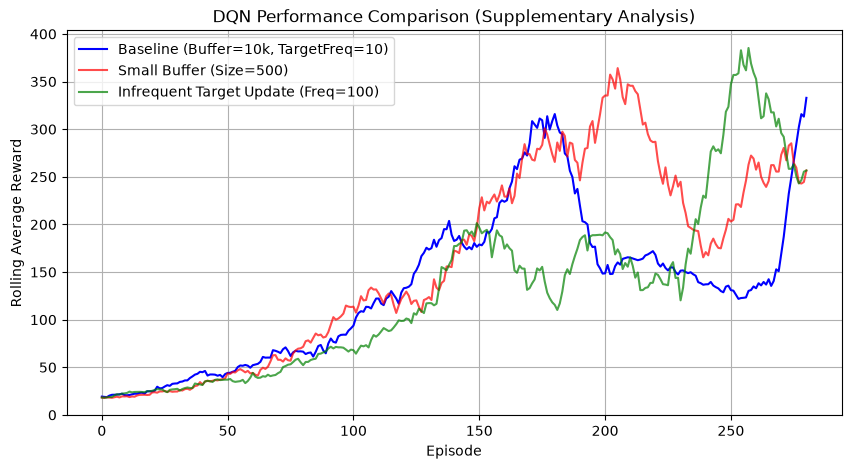

In [3]:
def train_dqn(
    env_name="CartPole-v1", episodes=300, buffer_size=10000, target_update_freq=10
):
    env = gym.make(env_name)

    initial_state, _ = env.reset()
    state_dim = len(initial_state)
    action_dim = int(getattr(env.action_space, "n", 2))

    agent = DQNAgent(
        state_dim,
        action_dim,
        buffer_size=buffer_size,
        target_update_freq=target_update_freq,
    )

    batch_size = 64
    epsilon = 1.0
    epsilon_min = 0.01
    epsilon_decay = 0.995

    rewards_history = []

    for ep in range(episodes):
        state, _ = env.reset()
        total_reward = 0.0
        done = False

        while not done:
            action = agent.select_action(state, epsilon)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            agent.memory.push(state, action, reward, next_state, done)
            agent.train_step(batch_size)

            state = next_state
            total_reward += float(reward)

        epsilon = max(epsilon_min, epsilon * epsilon_decay)
        rewards_history.append(total_reward)

    env.close()
    return rewards_history


# Run Baseline DQN
print("Training Baseline DQN...")
rewards_baseline = train_dqn(buffer_size=10000, target_update_freq=10)

# Supplementary Experiment 1: Small Replay Buffer
print("Training DQN with Small Replay Buffer (Size=500)...")
rewards_small_buffer = train_dqn(buffer_size=500, target_update_freq=10)

# Supplementary Experiment 2: Infrequent Target Update
print("Training DQN with Infrequent Target Update (Freq=100)...")
rewards_slow_target = train_dqn(buffer_size=10000, target_update_freq=100)


# Helper function to smooth curves
def moving_average(data, w=20):
    return np.convolve(data, np.ones(w) / w, mode="valid")


# Plot comparisons
plt.figure(figsize=(10, 5))
plt.plot(
    moving_average(rewards_baseline),
    label="Baseline (Buffer=10k, TargetFreq=10)",
    color="blue",
)
plt.plot(
    moving_average(rewards_small_buffer),
    label="Small Buffer (Size=500)",
    color="red",
    alpha=0.7,
)
plt.plot(
    moving_average(rewards_slow_target),
    label="Infrequent Target Update (Freq=100)",
    color="green",
    alpha=0.7,
)
plt.title("DQN Performance Comparison (Supplementary Analysis)")
plt.xlabel("Episode")
plt.ylabel("Rolling Average Reward")
plt.legend()
plt.grid(True)
plt.show()

## Key Questions

### 1. Why does Q-Learning fail in large state spaces?
* **Curse of Dimensionality:** Tabular Q-learning requires a discrete table entry for every possible state-action pair[cite: 16]. In environments with continuous variables (like joint angles in robotics) or high-dimensional inputs (like raw image pixels in game playing AI), the state space is effectively infinite[cite: 16]. 
* **Lack of Generalization:** A table cannot share knowledge between similar states. If the agent encounters a state that is only one pixel different from a known state, tabular Q-learning treats it as completely unseen.

### 2. How does a neural network approximate Q-values?
* Instead of storing values in a matrix, a Neural Network acts as a parameterized function approximator $Q(s, a; \theta) \approx Q^*(s, a)$[cite: 16]. 
* It takes the state vector $s$ as an input and outputs a continuous Q-value estimate for every possible discrete action[cite: 16]. It learns by minimizing the Mean Squared Error (MSE) between its current Q-value prediction and the target Q-value derived from the Bellman equation.

### 3. What is experience replay?
* **Experience Replay** is a memory buffer that stores past transition tuples $(S_t, A_t, R_{t+1}, S_{t+1}, \text{done})$ generated during environment interaction[cite: 16].
* During training, the agent samples randomized mini-batches from this buffer rather than training purely on consecutive frames. This breaks the temporal correlation of sequential observation data and allows the agent to learn from past successes and failures multiple times (improving sample efficiency)[cite: 16].

### 4. Why are target networks necessary?
* In the standard Q-learning update, the target value contains the term $\max_{a} Q(S_{t+1}, a; \theta)$. If the same network weights $\theta$ are used to calculate both the current prediction and the target, the target shifts every time the weights are updated (a "moving target")[cite: 16].
* This creates dangerous feedback loops and destabilizes training. A **Target Network** is a separate copy of the neural network with frozen parameters that are only synchronized with the main network periodically, ensuring stable target values during gradient descent[cite: 16].

---

## Supplementary Problems Analysis

### 1. Compare DQN with Tabular Q-Learning
* **Tabular Q-Learning:** Exact, guarantees convergence to the optimal policy in discrete environments, but cannot scale to complex or continuous environments.
* **DQN:** Can map continuous, high-dimensional observations to Q-values by generalizing visual/spatial features[cite: 16]. However, it loses the strict mathematical convergence guarantees of tabular methods.

### 2. Analyze replay buffer size
* **Too Small:** The buffer only holds recent transitions. The sampled batches become highly correlated, leading to catastrophic forgetting of older, distinct experiences[cite: 16].
* **Too Large:** The agent may sample overly outdated transitions that were generated by a much worse version of the policy, slowing down the refinement of the current optimal policy[cite: 16].

### 3. Evaluate target network update frequency
* **Too Frequent (e.g., every step):** Defeats the purpose of the target network, causing the moving target problem and training oscillations[cite: 16].
* **Too Infrequent:** The target values become excessively stale, drastically slowing down the propagation of newly discovered rewards and delaying convergence[cite: 16].